In [7]:
#Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
"""
1. Carry out the following data understanding and integrity checks
    a. How many rows and columns are present in the data?
    b. How many rows and how many columns have missing data?
"""

#a.How many rows and columns are present in the data?
df = pd.read_csv('patient-data.csv')
rows, columns = df.shape
print(f'No. of rows: {rows}')
print(f'No. of columns: {columns}')

# How many rows and how many columns have missing data?
cols_with_missing_data = df.isnull().any().sum()
print(f'No. of columns with missing data: {cols_with_missing_data}')

rows_with_missing_data = df.isnull().any(axis=1).sum()
print(f'No. of rows with missing data: {rows_with_missing_data}')
print(f'%. of rows with missing data: {(rows_with_missing_data / rows) * 100:.2f}%')


No. of rows: 2371
No. of columns: 25
No. of columns with missing data: 21
No. of rows with missing data: 4
%. of rows with missing data: 0.17%


In [9]:
# 2. Identify the level of measurement associated with each column
print('--------Data Type of each column---------')
print(df.info())
print('--------Missing values per column---------')
print(df.isnull().sum()[df.isnull().sum() > 0])


--------Data Type of each column---------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2371 entries, 0 to 2370
Data columns (total 25 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   p01      2371 non-null   float64
 1   p02      2371 non-null   float64
 2   p03      2370 non-null   float64
 3   p04      2370 non-null   float64
 4   p05      2370 non-null   float64
 5   p06      2370 non-null   float64
 6   p07      2370 non-null   float64
 7   p08      2370 non-null   float64
 8   p09      2370 non-null   float64
 9   p10      2370 non-null   float64
 10  p11      2370 non-null   float64
 11  p12      2370 non-null   float64
 12  p13      2370 non-null   float64
 13  p14      2370 non-null   float64
 14  p15      2369 non-null   float64
 15  p16      2369 non-null   float64
 16  p17      2370 non-null   float64
 17  p18      2370 non-null   float64
 18  p19      2370 non-null   float64
 19  p20      2370 non-null   float64
 20  p21      2

In [10]:
"""
3.  Create appropriate Descriptive Statistics information for every column, based on it’s level of
    measurement, and organize all this data in Tables for easy analysis and decision making.
        a. Analyze the descriptive statistics thus generated and make your initial conclusions
"""

numeric_df = df.select_dtypes(include=['number'])
desc = numeric_df.describe().T

desc['skewness'] = numeric_df.skew()
desc['kurtosis'] = numeric_df.kurtosis()

desc = desc.round(5)
print(desc)

"""
Observations :
    1. Variation across physiological parameters:

        a. Some variables (like p04, p05) have large ranges, suggesting these might represent quantitative lab measures with wide patient variability.

        b. Others (like p06, p22, p23) show small ranges, likely indicating standardized or ratio-based metrics.

    2. Outliers and distribution:

        a. A few features (p04, p05, p17) show large standard deviations relative to their means, indicating possible outliers or heterogeneity among patient groups.
"""

      count          mean          std       min           25%           50%  \
p01  2371.0      95.72359     18.39131      70.0      79.04528      94.91051   
p02  2371.0     157.05607     20.08663     125.0     140.42847     157.33415   
p03  2370.0      15.87582      1.10812      13.5      14.84110      15.97608   
p04  2370.0  299642.03349  92072.55435  150000.0  207236.90420  308502.92160   
p05  2370.0    7576.39282   1975.40715    4000.0    5779.74322    7692.15344   
p06  2370.0       4.78141      0.33451       4.2       4.47509       4.73111   
p07  2370.0      45.17637      4.13093      38.0      42.00627      44.98234   
p08  2370.0      89.36884      5.81042      80.0      85.07402      88.56483   
p09  2370.0      30.01276      1.96481      27.0      28.29254      29.61875   
p10  2370.0      34.28816      1.12856      32.0      33.44048      34.46403   
p11  2370.0      13.85388      5.19732       5.0       8.96678      13.80662   
p12  2370.0      21.54988      1.75758  

'\nObservations :\n    1. Variation across physiological parameters:\n\n        a. Some variables (like p04, p05) have large ranges, suggesting these might represent quantitative lab measures with wide patient variability.\n\n        b. Others (like p06, p22, p23) show small ranges, likely indicating standardized or ratio-based metrics.\n\n    2. Outliers and distribution:\n\n        a. A few features (p04, p05, p17) show large standard deviations relative to their means, indicating possible outliers or heterogeneity among patient groups.\n'

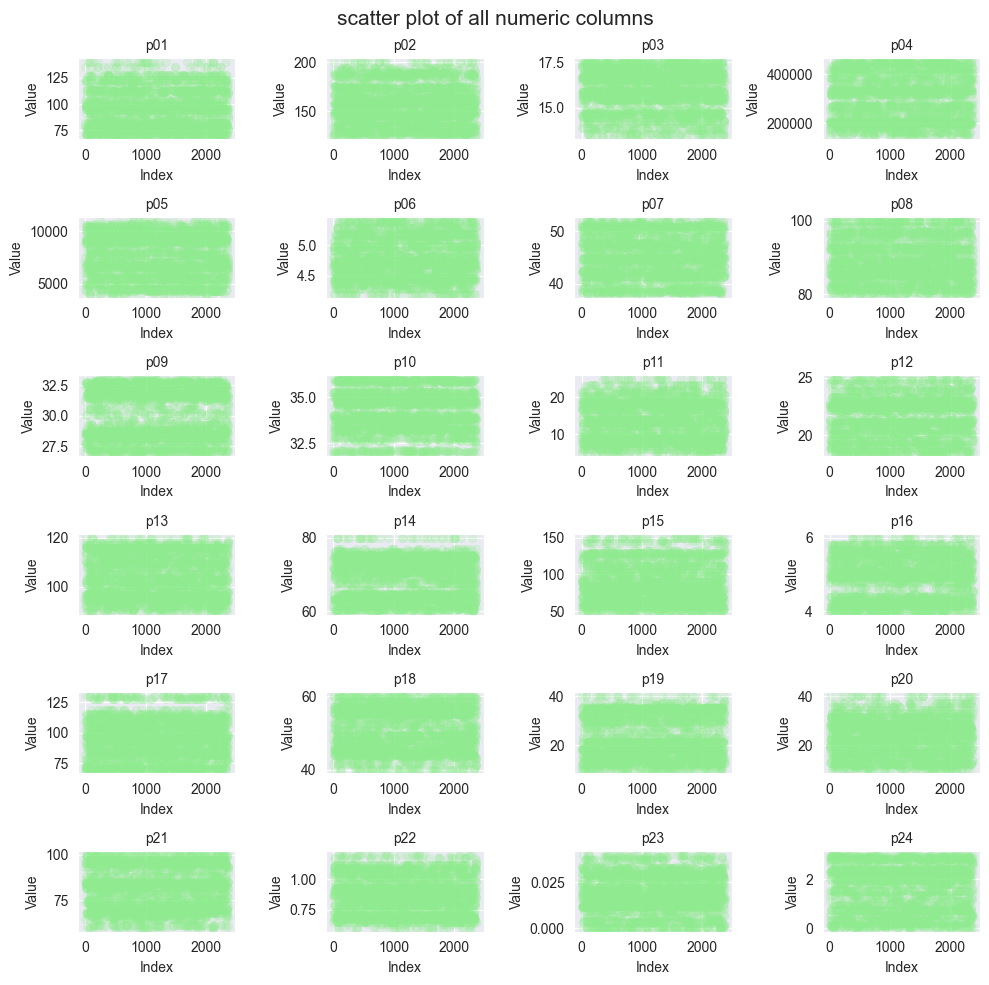

In [68]:
"""
4. Is this data a time-series data? Do you expect any trends in each of the columns? Can you make any conclusions by creating a scatter plot of values of each column?
"""
#%pip install seaborn
fig, axes = plt.subplots(6, 4, figsize=(10, 10))
axes = axes.flatten()
num_columns = df.select_dtypes(include=['number']).columns

for i, col in enumerate(num_columns):
    sns.scatterplot(x=df.index, y=df[col], ax=axes[i], color='lightgreen', alpha=0.2, edgecolor=None)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("Index")
    axes[i].set_ylabel("Value")

plt.suptitle('scatter plot of all numeric columns', fontsize=15)
plt.tight_layout()
plt.show()

In [12]:
"""
5.Based on the information available so far, what will be your strategy for dealing with the missing values?
    Make some initial decisions at this stage.
"""

"""
 - We can remove the missing values as it contributes only 0.17% of total data
 - You don’t want to make assumptions by imputing
"""

df_clean = df.dropna()
print(df_clean.head())

          p01         p02        p03          p04          p05       p06  \
0  123.267876  178.595162  16.399606  410204.1015  8834.625206  4.809562   
1   78.099990  125.917170  17.343260  421416.3821  7551.743543  4.650226   
2  102.281198  133.735334  15.709720  267971.2381  6030.085265  4.623836   
3   79.183690  125.291132  15.201283  204385.8555  4507.019659  4.352788   
4   82.117428  187.164685  17.452967  384908.4868  7096.110188  4.696469   

         p07        p08        p09        p10  ...       p16         p17  \
0  42.033429  92.318682  27.004825  35.257693  ...  5.041603   81.518196   
1  40.209919  85.496273  28.292545  34.059034  ...  5.799974  109.089298   
2  46.893548  85.234094  32.408743  32.082015  ...  4.964792   92.357938   
3  38.891841  93.113226  27.778412  34.040408  ...  4.000000   70.448002   
4  50.803614  88.335091  28.600120  35.299643  ...  4.884780   77.147088   

         p18        p19        p20        p21       p22       p23       p24  \
0  49.9

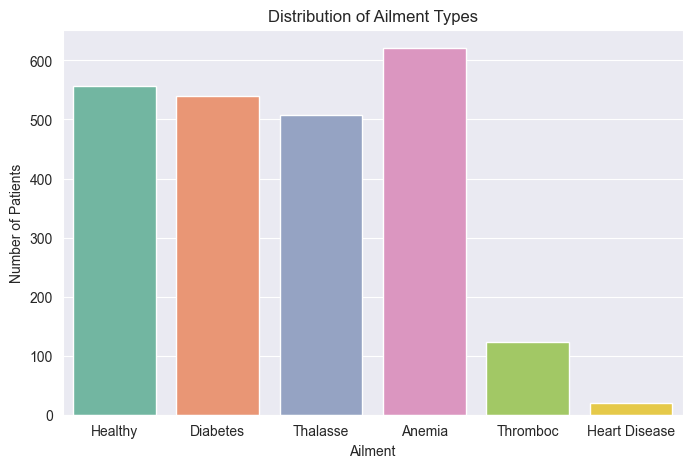

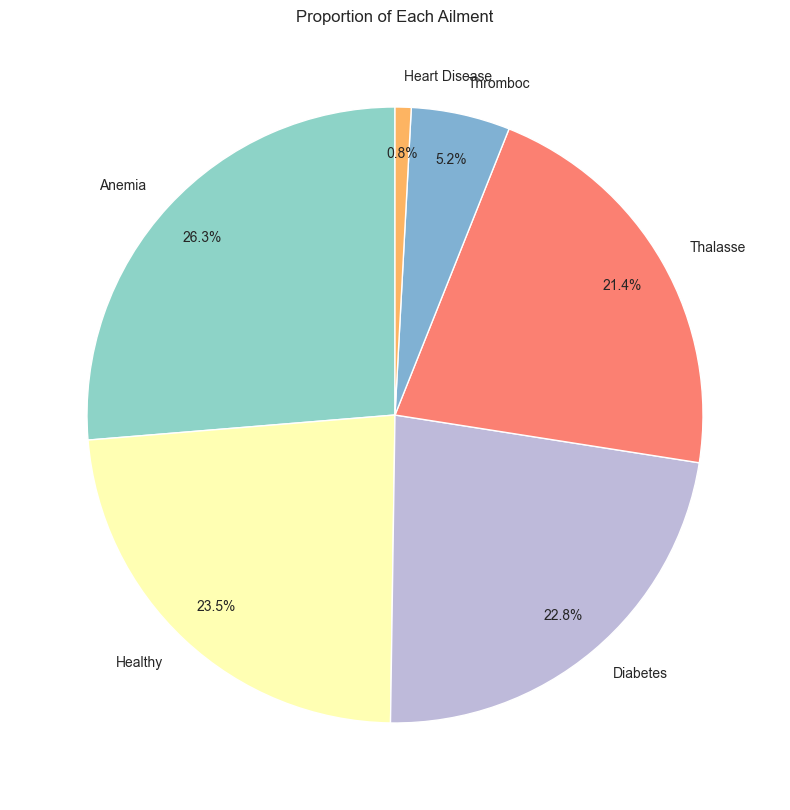

Missing Ailment values: 2
------------------------------------------------------------------------------------------------------------------------------------------------------
--------Cleaned up dataframe-------------
          p01         p02        p03          p04          p05       p06  \
0  123.267876  178.595162  16.399606  410204.1015  8834.625206  4.809562   
1   78.099990  125.917170  17.343260  421416.3821  7551.743543  4.650226   
2  102.281198  133.735334  15.709720  267971.2381  6030.085265  4.623836   
3   79.183690  125.291132  15.201283  204385.8555  4507.019659  4.352788   
4   82.117428  187.164685  17.452967  384908.4868  7096.110188  4.696469   

         p07        p08        p09        p10  ...       p16         p17  \
0  42.033429  92.318682  27.004825  35.257693  ...  5.041603   81.518196   
1  40.209919  85.496273  28.292545  34.059034  ...  5.799974  109.089298   
2  46.893548  85.234094  32.408743  32.082015  ...  4.964792   92.357938   
3  38.891841  93.113

'\nHandling of missing data :-\n\nAs there are only 2 data points missing, which is less than 5% of total that, we can remove those rows\n'

In [13]:
"""
6. Analyze the Ailment column with the help of appropriate visualizations. What can you conclude? Are there any missing values in this column? How will you handle them? Why?
"""

# Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Ailment', palette='Set2', hue='Ailment')
plt.title('Distribution of Ailment Types')
plt.xlabel('Ailment')
plt.ylabel('Number of Patients')
plt.show()

#Pie Chart
plt.figure(figsize=(10, 10))
df['Ailment'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'),
                                      labeldistance=1.1, pctdistance=0.85)
plt.title('Proportion of Each Ailment')
plt.ylabel('')
plt.show()

#Missing Values
missing_ailment = df['Ailment'].isnull().sum()
print(f"Missing Ailment values: {missing_ailment}")
print("---" * 50)
# Cleaned up Dataframe
print("--------Cleaned up dataframe-------------")
print(df_clean.head())

"""
Handling of missing data :-

As there are only 2 data points missing, which is less than 5% of total that, we can remove those rows
"""

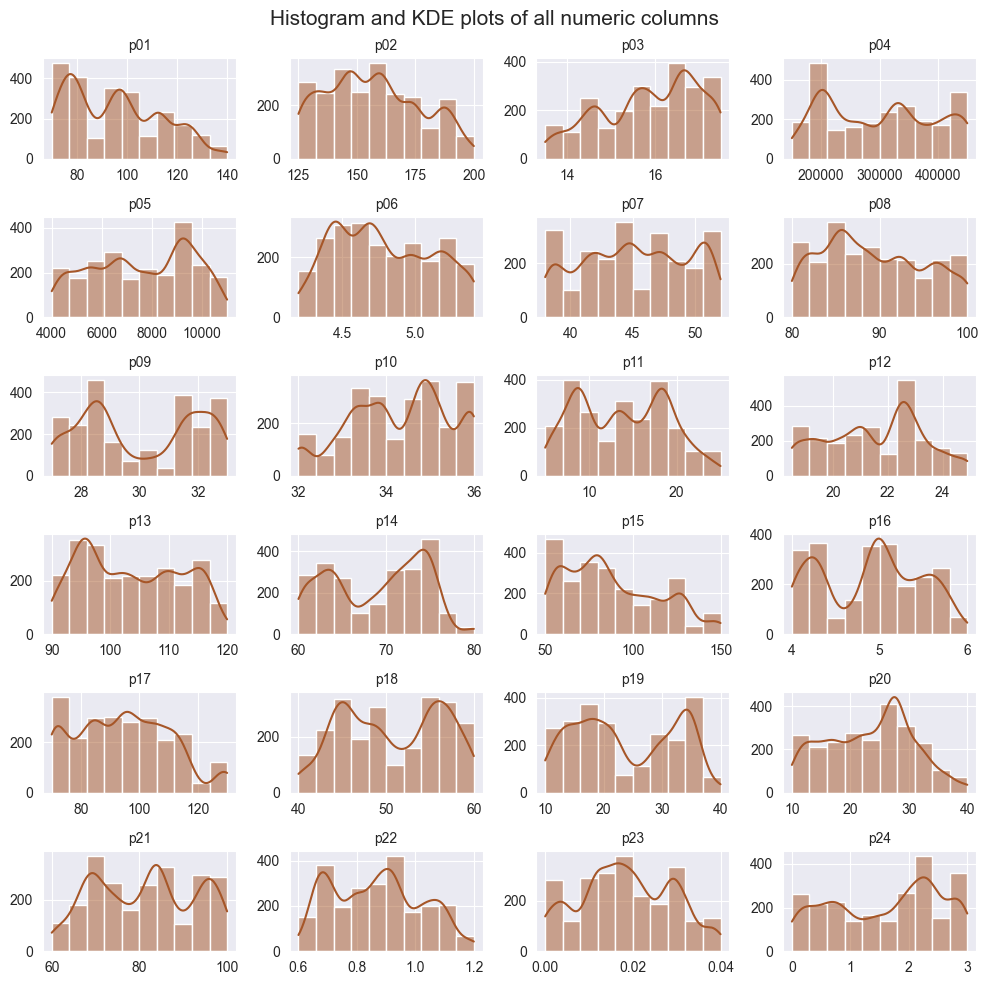

'\nObservations :\n\n1. The dataset shows mixed distribution patterns — some normal-like, others multimodal or skewed.\n2. Multiple peaks in several columns may indicate underlying groups or categories\n3. Few variables (like p04, p05) dominate in scale → scaling/normalization will be essential before modeling.\n4. No column shows extreme outlier clusters, indicating reasonably clean numeric data.\n'

In [50]:
"""
7. Create histograms and KDE plots (find out what KDE plots represent) for all the columns and analyze
them. Any significant conclusions?
"""

fig, axes = plt.subplots(6, 4, figsize=(10, 10))
axes = axes.flatten()
num_columns = df_clean.select_dtypes(include=['number']).columns

for i, col in enumerate(num_columns):
    sns.histplot(df_clean[col], ax=axes[i], kde=True, color=sns.color_palette('Set1')[6], bins=10)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.suptitle('Histogram and KDE plots of all numeric columns', fontsize=15)
plt.tight_layout()
plt.show()

"""
Observations :

1. The dataset shows mixed distribution patterns — some normal-like, others multimodal or skewed.
2. Multiple peaks in several columns may indicate underlying groups or categories
3. Few variables (like p04, p05) dominate in scale → scaling/normalization will be essential before modeling.
4. No column shows extreme outlier clusters, indicating reasonably clean numeric data.
"""

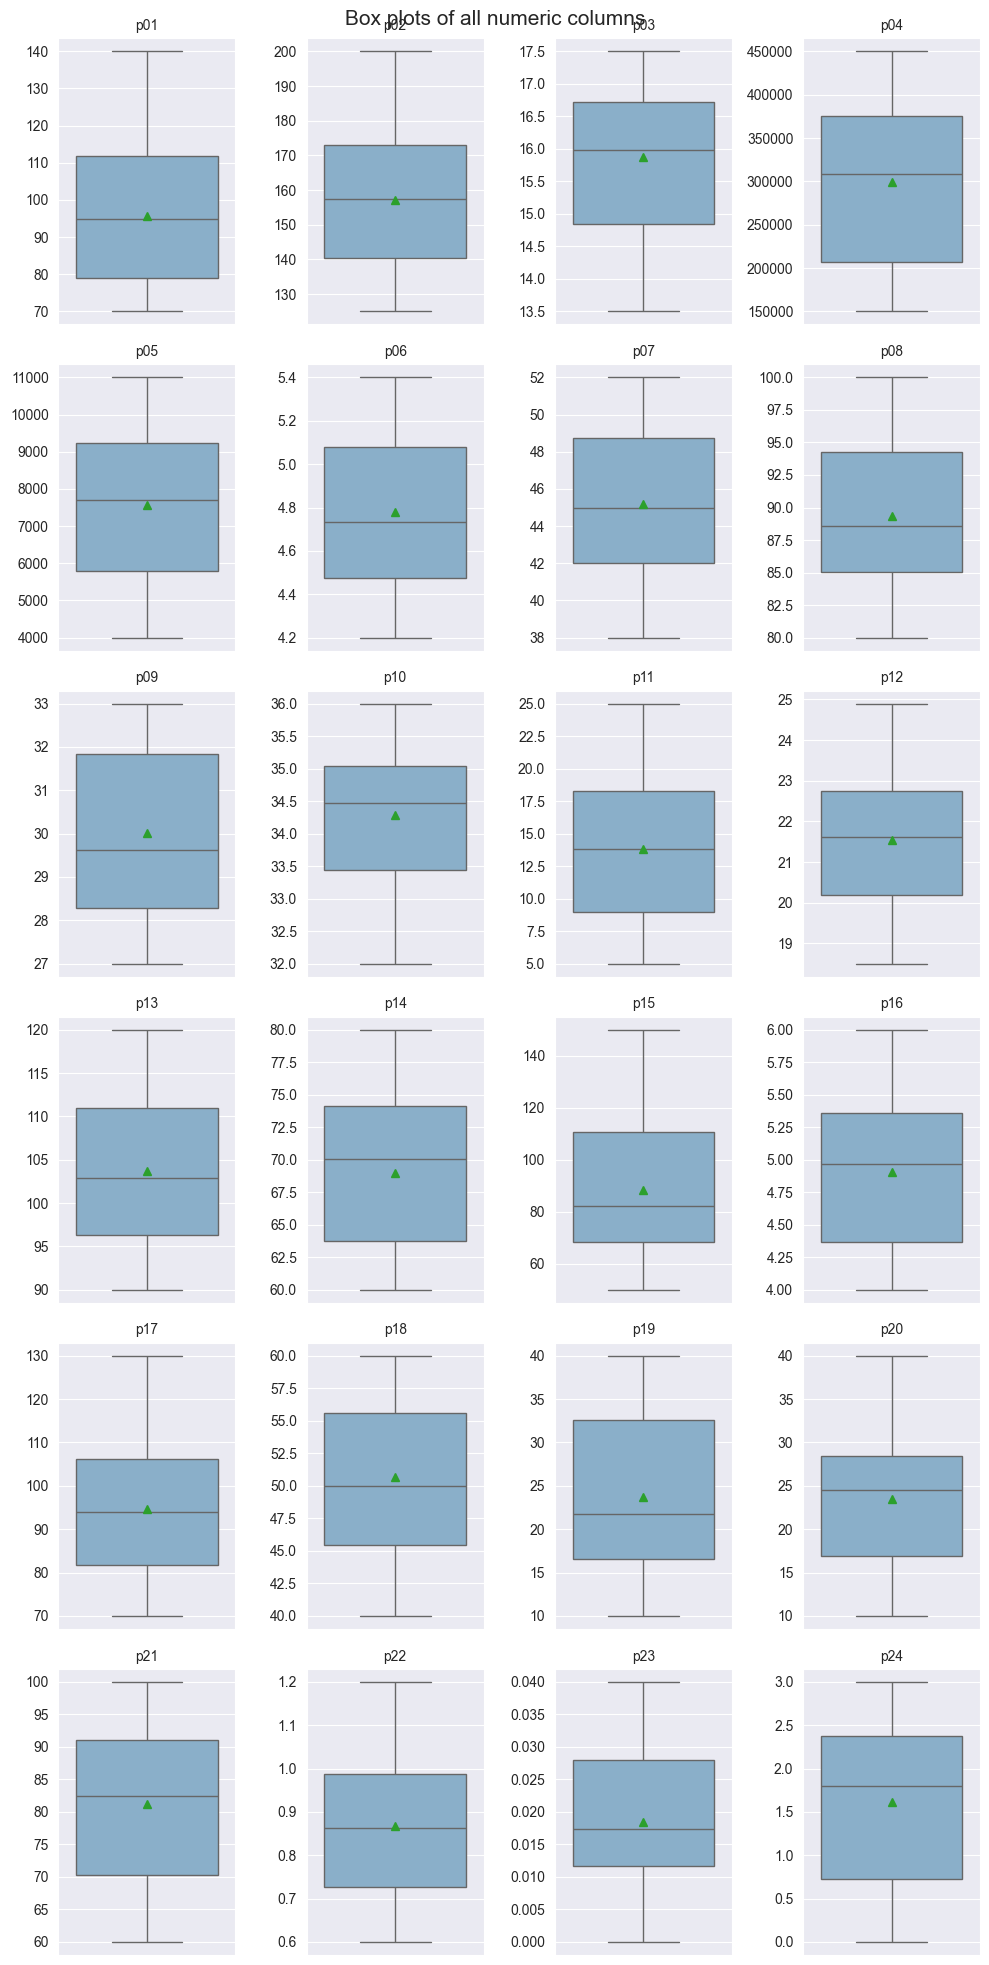

In [46]:
"""
8. Create box plots for all the columns, individually, and analyze them. What are your conclusions?
"""

fig, axes = plt.subplots(6, 4, figsize=(10, 20))
axes = axes.flatten()
num_columns = df_clean.select_dtypes(include=['number']).columns

for i, col in enumerate(num_columns):
    sns.boxplot(y=df[col], ax=axes[i], color=sns.color_palette('Set3')[4], orient='v', showmeans=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('')

plt.suptitle('Box plots of all numeric columns', fontsize=15)
plt.tight_layout()
plt.show()

"""
Observations :
1. p01, p02, p05, p09, p10, p13, p17, p19, p20 — mean slightly above median → mild right skew.
2. p03, p04, p14, p15 — mean below median → mild left skew.
3. The rest look approximately symmetric.
4. No extreme outliers are visible — whiskers are even and smooth. Data seems fairly clean
5. Some columns (like p04, p05, p13) have much larger numerical ranges than others (e.g., p22, p23).
"""

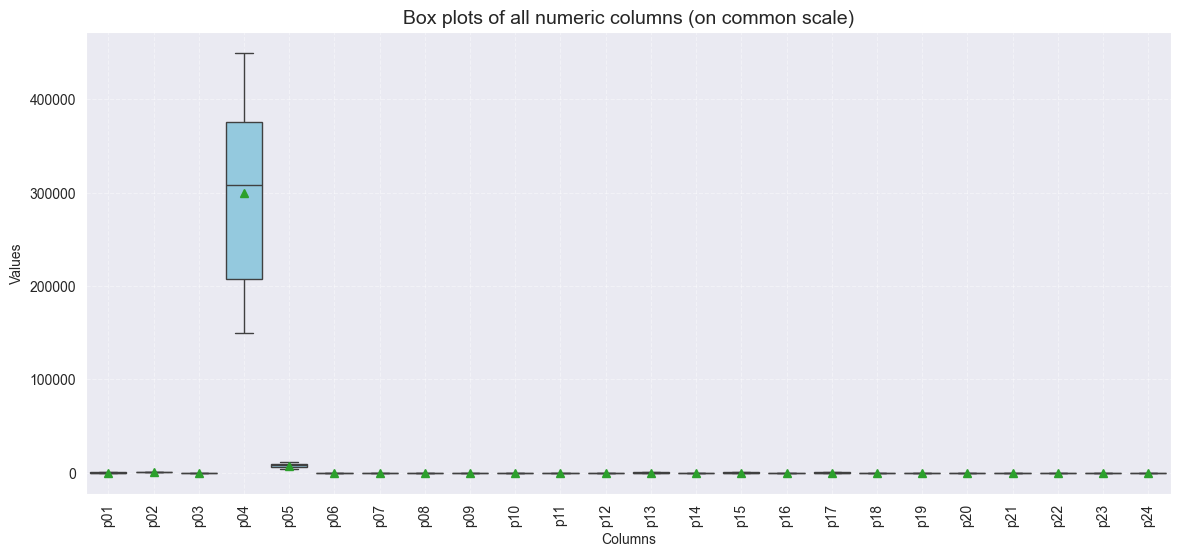

'\nObservations:\n1 . Differences in Scale\n    Columns like p04 and p05 have very high numeric ranges (hundreds of thousands or tens of thousands).\n    Others like p06, p16, p22, p23 are small-valued (e.g., in single digits or decimal range).\n\n2. There are no outliers in any of the columns\n\n3. We need to standardization or normalization before creating the model\n'

In [52]:
"""
9. Create box plots for all the numerical columns on a common scale, and in a single plot, and analyze this plot. What do you observe? What are its implications?
"""

numeric_df = df_clean.select_dtypes(include='number')

plt.figure(figsize=(14, 6))
sns.boxplot(data=numeric_df, showmeans=True, color='SkyBlue')

plt.title('Box plots of all numeric columns (on common scale)', fontsize=14)
plt.xlabel('Columns')
plt.ylabel('Values')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

"""
Observations:
1 . Differences in Scale
    Columns like p04 and p05 have very high numeric ranges (hundreds of thousands or tens of thousands).
    Others like p06, p16, p22, p23 are small-valued (e.g., in single digits or decimal range).

2. There are no outliers in any of the columns

3. We need to standardization or normalization before creating the model
"""

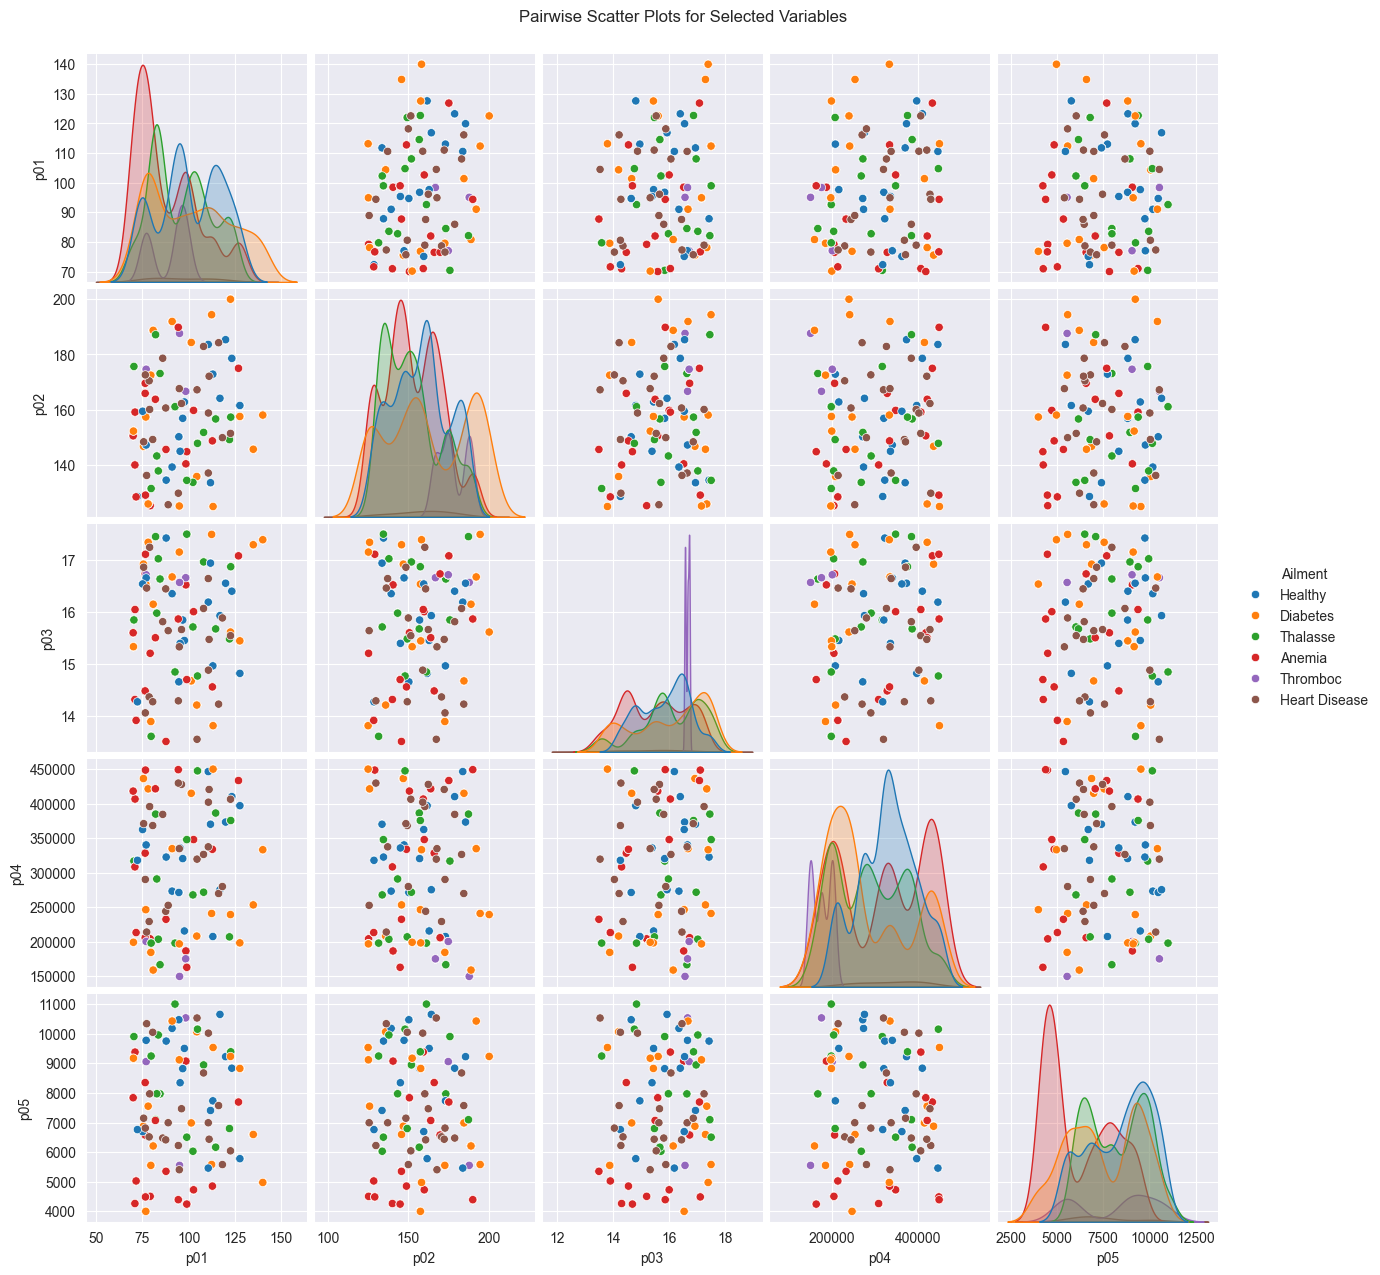

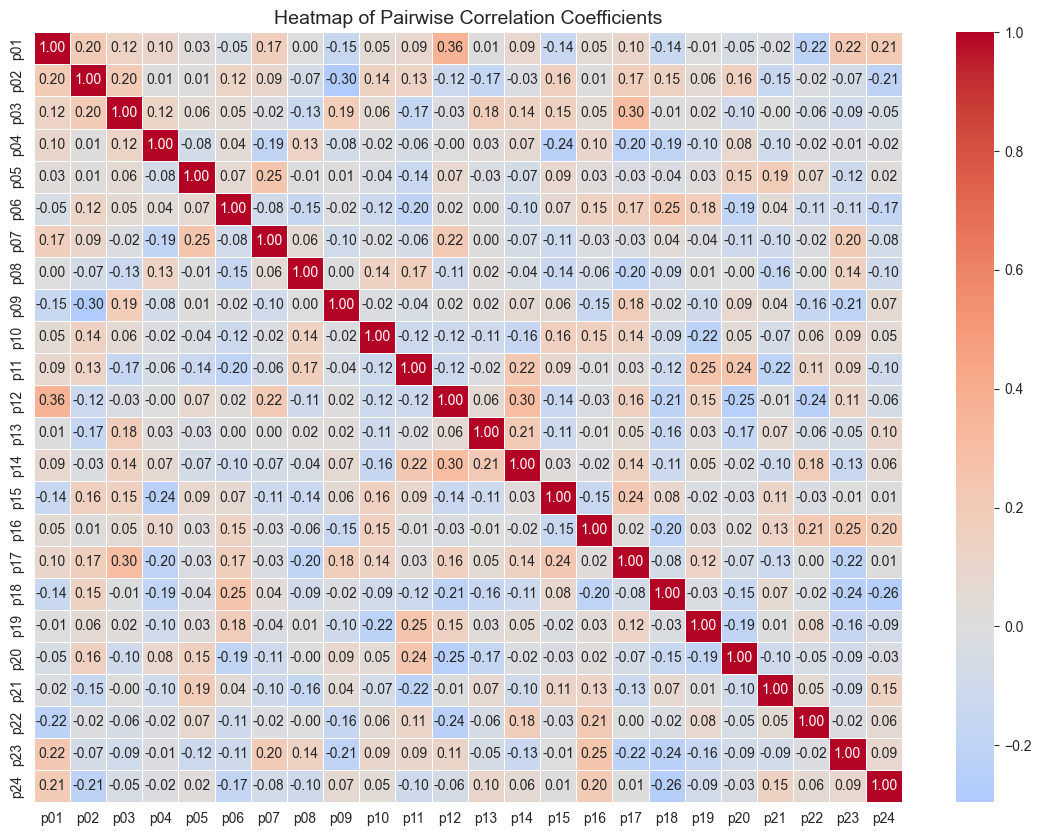

In [78]:
"""
10. To understand the relationships between the columns, create the following:
    a. Pairwise scatter plots
    b. Heatmap of pairwise correlation coefficients
    c. What are your conclusions based on these plots?
"""

# a. Pairwise scatter plots
num_columns = df_clean.select_dtypes(include=['number']).columns
sns.pairplot(df_clean, vars=num_columns[:5], hue='Ailment', diag_kind='kde')
plt.suptitle("Pairwise Scatter Plots for Selected Variables", y=1.02)
plt.show()

# b. Heatmap
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap of Pairwise Correlation Coefficients', fontsize=14)
plt.show()

#c. Conclusion
"""
Features are independent of each other . We need to retain all features as each my add unique information
"""

**11. Based on all the analysis so far, what is your final conclusion regarding the handling of missing values?
Implement your decision!**

    We have decided to remove all rows having missing values as they constitute  < 1% of the total data, so can be safely removed
    df_clean contains the dataframe after dropping all missing values